In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import missingno as msno

R에서 시각화하는 방법과 유사한 시각화를 사용하기 위해서 라이브러러를 설치하고 import 한다.

In [2]:
# !pip install plotnine
from plotnine import *

In [3]:
# 현재 작업중인 소스프로그램이 위치한 경로
%pwd

'D:\\samsung_1\\python\\data_analysis\\workspace'

In [4]:
# 현자 작업중인 소스프로그램이 위치한 경로와 파일 목록
%ls data
# '%ls 폴더이름' 형태로 실행하면 현재 소스프로그램이 위치한 경로 아래의 지정한 폴더 내부의 파일 목록을 보여준다.

 D 드라이브의 볼륨: DATA
 볼륨 일련 번호: 2E74-B032

 D:\samsung_1\python\data_analysis\workspace\data 디렉터리

2026-07-06  오후 02:38    <DIR>          .
2026-07-06  오후 03:28    <DIR>          ..
2024-04-24  오후 04:50             1,011 [필독]파일열람방법.txt
2020-03-24  오후 10:09           148,570 alice.txt
2024-05-08  오후 01:14           257,386 bike_20240508.csv
2024-05-08  오후 03:03           257,434 bike_20240508_ok.csv
2024-05-08  오후 03:01           199,274 bike_df_map.csv
2018-09-05  오전 11:23                61 concat_1.csv
2018-09-05  오전 11:23                61 concat_2.csv
2018-09-05  오전 11:23                69 concat_3.csv
2018-09-05  오전 11:23             5,796 country_timeseries.csv
2023-09-01  오후 04:54           545,925 ebook.txt
2018-09-05  오전 11:23            83,637 gapminder.tsv
2022-12-30  오후 05:56           493,659 muk_01.txt
2024-05-07  오후 02:48         3,862,120 park_202405.csv
2024-05-07  오후 04:45         5,000,640 park_202405_ok.csv
2024-05-01  오전 11:13           358,739 perSale_2023_06.csv
2026

2015년 10월부터 2026년 5월까지 주택분양보증을 받아 분양한 전체 민간 신규 아파트 분양가격 동향

공공데이터포털(https://www.data.go.kr/)에서 '민간아파트'를 검색한다.  
<img src="./민간아파트1.png" width="1000" align="left" />

<img src="./민간아파트2.png" width="1000" align="left" />

분석하기 위해 데이터가 저장된 csv 파일을 읽는다.

pandas의 read_csv() 메소드로 csv 파일이나 tsv 파일을 읽을때 한글 인코딩 문제로 'utf-8' codec can't decode byte 0xc1 in position 0: invalid start byte 에러가 발생될 수 있다. => 높은 확률로 엑셀에서 바로 열릴 경우

In [5]:
# pd.read_csv('./data/perSale_2026_05.csv')가 UnicodeDecodeError 에러가 발생되면 일반적으로 encoding='utf-8'을 추가하는데 추가해도 UnicodeDecodeError가 
# 발생하면 csv 파일의 파일 형식이 'ANSI'일 경우이다. 이럴 경우에는 encoding 속성에 'cp949' 또는 'euc-kr'지정하면 된다.
perSale_df = pd.read_csv('./data/perSale_2026_05.csv', encoding='euc-kr')
print(perSale_df.shape)
perSale_df.head()

(10880, 5)


,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879


encoding 속성을 지정하기 않고 사용하려면 csv 파일을 메모장으로 열고 파일 메뉴의 다른 이름으로 저장에서 인코딩 방식을 ANSI에서 UTF-8로 변경한 후 저장해서 덮어쓰기를 하면 읽어올 수 있다.

<img src="./민간아파트3.png" width="1000" align="left" />

dtypes 속성이나 info() 메소드를 이요해서 데이터프레임을 구성하는 각 시리즈(열)의 데이터 타입을 확인하고 필요하다면 데이터 타입을 변경한다.

In [6]:
perSale_df.dtypes

지역명                 str
규모구분                str
연도                int64
월                 int64
분양가격(제곱미터당 천원)      str
dtype: object

In [7]:
perSale_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   지역명             10880 non-null  str  
 1   규모구분            10880 non-null  str  
 2   연도              10880 non-null  int64
 3   월               10880 non-null  int64
 4   분양가격(제곱미터당 천원)  10035 non-null  str  
dtypes: int64(2), str(3)
memory usage: 425.1 KB


연도와 월은 연산에 사용되는 데이터가 아니라 구분에 사용되는 범주형 데이터이므로 astype() 메소드로 문자열로 변환한다.

데이터프레임의 특정 열 1개(시리즈)를 얻어올 때 "데이터프레임['열이름'], 데이터프레임.get('열이름'), 데이터프레임.열이름"과 같이 3가지 방식이 모두 사용가능하지만 2개 이상의 열을 얻어올때는 "데이터프레임.열이름" 방법은 사용할 수 없다.

In [8]:
# perSale_df['연도'] = perSale_df['연도'].astype(str)
# perSale_df['연도'] = perSale_df.get('연도').astype(str)
perSale_df['연도'] = perSale_df.연도.astype(str) # 2개 이상의 열은 얻어올 수 없다.

데이터프레임의 특정 열 1개(시리즈)를 얻어올 때 "데이터프레임['열이름'], 데이터프레임.get('열이름'), 데이터프레임.열이름"과 같이 3가지 방식이 모두 사용가능하지만 데이터프레임의 특정 열에 넣어줄때는 "데이터프레임.get('열이름')" 방식은 사용할 수 없다.

In [9]:
# perSale_df['월'] = perSale_df['월'].astype(str)
# perSale_df.get('월') = perSale_df.get('월').astype(str) # 에러
perSale_df.월 = perSale_df.월.astype(str)

분양가격(제곱미터당 천원) 열은 연산에 사용할 데이터이므로 숫자로 변경한다.

astype() 메소드는 문자열을 숫자로 변경하려는 경우 숫자가 아닌 문자열이 있으면 에러가 발생된다. 이럴 경우 to_numeric() 메소드를 사용해서 숫자로 변경할 때 에러가 발생되면 errors 속성의 속성값을 'coerce'로 지정해서 누락값(NaN)으로 처리한다.

In [10]:
# perSale_df['분양가격(제곱미터당 천원)'] = perSale_df['분양가격(제곱미터당 천원)'].astype(float) # 문자열 때문에 에러발생
perSale_df['분양가격(제곱미터당 천원)'] = pd.to_numeric(perSale_df['분양가격(제곱미터당 천원)'], errors='coerce')

숫자로 변경된 '분양가격(제곱미터당 천원)' 열을 이용해서 '평당분양가격'을 계산한 파생 변수를 추가한다.

In [11]:
perSale_df['평당분양가격'] = perSale_df['분양가격(제곱미터당 천원)'] * 3.3
perSale_df.tail()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),평당분양가격
10875,제주,모든면적,2026,5,4473.0,14760.9
10876,제주,전용면적 60제곱미터이하,2026,5,NaN,NaN
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485.0,14800.5
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN,NaN
10879,제주,전용면적 102제곱미터초과,2026,5,4350.0,14355.0


In [12]:
perSale_df.dtypes

지역명                   str
규모구분                  str
연도                    str
월                     str
분양가격(제곱미터당 천원)    float64
평당분양가격            float64
dtype: object

누락값을 확인한다.

isnull() 메소드와 sum() 메소드를 사용해서 누락값이 존재하는가 확인한다.

In [14]:
print(perSale_df.isnull().sum())

지역명                 0
규모구분                0
연도                  0
월                   0
분양가격(제곱미터당 천원)    973
평당분양가격            973
dtype: int64


missingno 라이브러리를 이용해서 누락값 분포 확인하기 => 흰색으로 보이는 부분이 누락값이다.

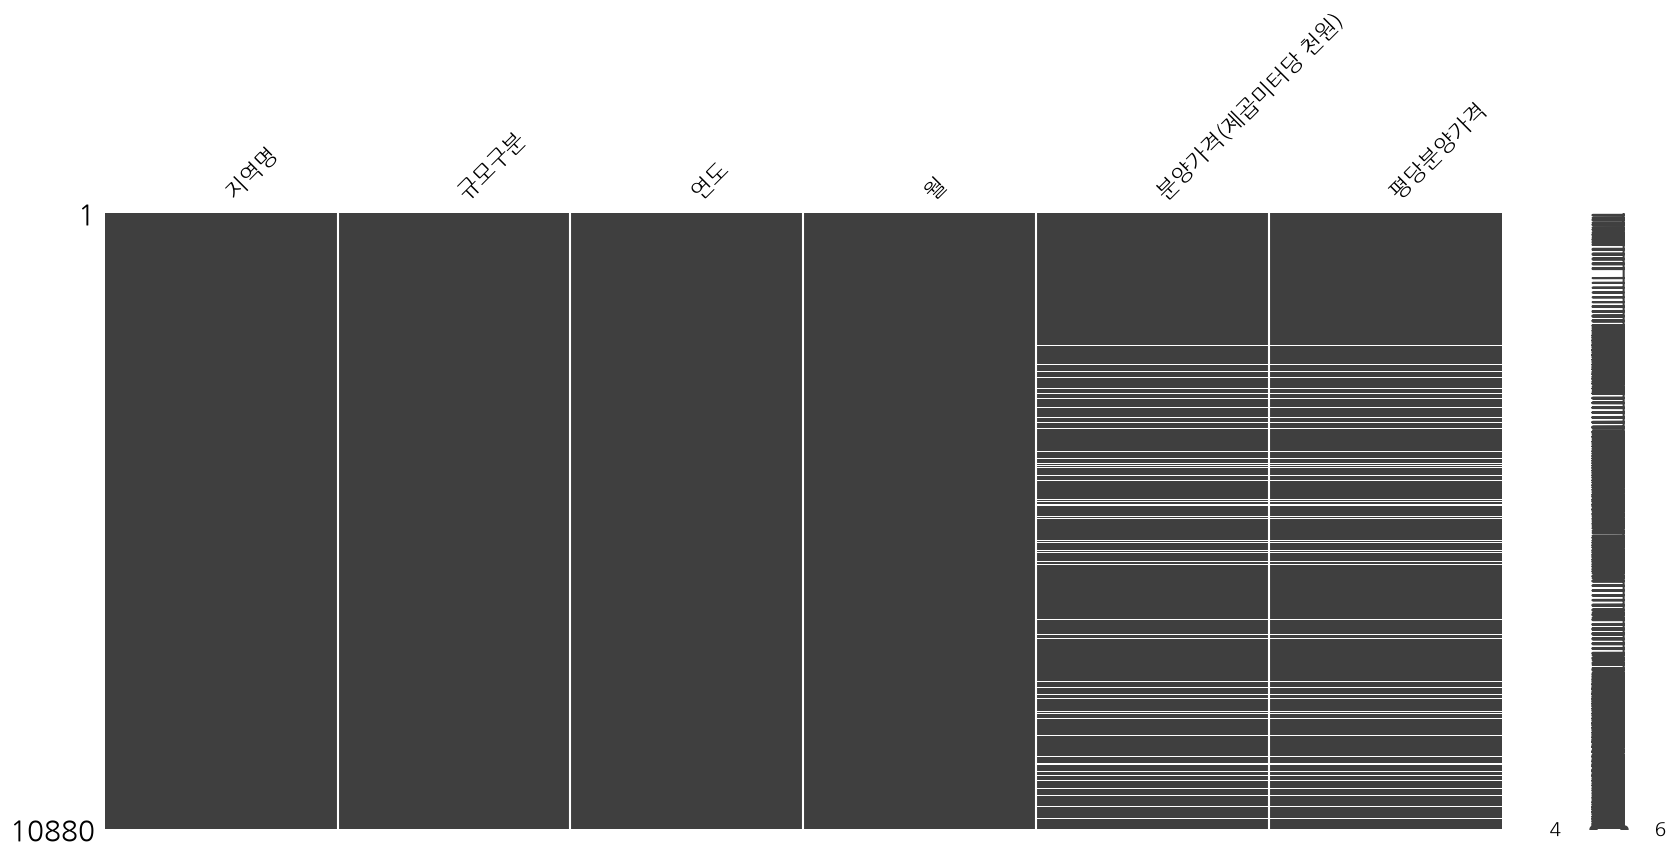

In [19]:
msno.matrix(perSale_df, figsize=[20, 8])
plt.show()

브로드캐스팅을 이용한 불린 인덱싱을 사용해서 2025년 데이터만 추출한다.

In [21]:
perSale_df_2025 = perSale_df[perSale_df.연도 == '2025']
print(perSale_df_2025.shape)
perSale_df_2025

(1020, 6)


,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),평당분양가격
9435,서울,모든면적,2025,1,13350.0,44055.0
9436,서울,전용면적 60제곱미터이하,2025,1,13508.0,44576.4
9437,서울,전용면적 60제곱미터초과 85제곱미터이하,2025,1,13967.0,46091.1
9438,서울,전용면적 85제곱미터초과 102제곱미터이하,2025,1,15033.0,49608.9
9439,서울,전용면적 102제곱미터초과,2025,1,14078.0,46457.4
...,...,...,...,...,...,...
10450,제주,모든면적,2025,12,NaN,NaN
10451,제주,전용면적 60제곱미터이하,2025,12,NaN,NaN
10452,제주,전용면적 60제곱미터초과 85제곱미터이하,2025,12,NaN,NaN
10453,제주,전용면적 85제곱미터초과 102제곱미터이하,2025,12,NaN,NaN


In [25]:
# 지역별 데이터가 동일하게 저장되어 있다.
# count() 메소드는 전체 데이터의 개수를 센다.
# perSale_df.지역명.count()
# value_counts() 메소드는 시리즈에 저장된 값이 같은 데이터의 개수를 센다.
perSale_df.지역명.value_counts()

지역명
서울    640
인천    640
경기    640
부산    640
대구    640
광주    640
대전    640
울산    640
세종    640
강원    640
충북    640
충남    640
전북    640
전남    640
경북    640
경남    640
제주    640
Name: count, dtype: int64

In [26]:
# 규모구분별 데이터도 동일하게 저장되어 있다.
perSale_df.규모구분.value_counts()

규모구분
모든면적                       2176
전용면적 60제곱미터이하              2176
전용면적 60제곱미터초과 85제곱미터이하     2176
전용면적 85제곱미터초과 102제곱미터이하    2176
전용면적 102제곱미터초과             2176
Name: count, dtype: int64

전국 연도별 평균 평당분양가격

In [28]:
perSale_df.groupby('연도')['평당분양가격'].mean()

연도
2015     9202.735802
2016     9683.025000
2017    10372.928923
2018    10978.938411
2019    12188.293092
2020    13039.422449
2021    13636.022540
2022    14942.504494
2023    16890.920657
2024    19193.255439
2025    20058.105823
2026    21111.425266
Name: 평당분양가격, dtype: float64

전국 연도별 규모구분별 평균 평당분양가격

In [29]:
perSale_df.groupby(['연도', '규모구분'])['평당분양가격'].mean()

연도    규모구분                   
2015  모든면적                        8893.047059
      전용면적 102제곱미터초과              9837.226667
      전용면적 60제곱미터이하               8951.525000
      전용면적 60제곱미터초과 85제곱미터이하      8891.817647
      전용면적 85제곱미터초과 102제곱미터이하     9518.506250
2016  모든면적                        9293.042647
      전용면적 102제곱미터초과             10388.728272
      전용면적 60제곱미터이하               9398.876119
      전용면적 60제곱미터초과 85제곱미터이하      9295.986765
      전용면적 85제곱미터초과 102제곱미터이하    10122.355435
2017  모든면적                        9927.322059
      전용면적 102제곱미터초과             11311.244162
      전용면적 60제곱미터이하              10271.375635
      전용면적 60제곱미터초과 85제곱미터이하      9840.438235
      전용면적 85제곱미터초과 102제곱미터이하    10573.447977
2018  모든면적                       10675.825123
      전용면적 102제곱미터초과             11445.574576
      전용면적 60제곱미터이하              10844.409783
      전용면적 60제곱미터초과 85제곱미터이하     10650.611823
      전용면적 85제곱미터초과 102제곱미터이하    11441.707895
2019  모든면적                       11602.715816
    

pd.options.display.float_format을 사용해서 데이터프레임에 저장된 실수 데이터의 출력 형식을 지정할 수 있다.  
{:,.1f}는 천 단위마다 ','를 출력하고 '.'뒤의 숫자만큼 소수점 아래 자리를 표시한다.  
'f'를 생략하거나 'e'를 사용하면 지수 형태로 표시된다.

In [36]:
pd.options.display.float_format = '{:,.1f}'.format
perSale_df

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),평당분양가격
0,서울,모든면적,2015,10,"5,841.0","19,275.3"
1,서울,전용면적 60제곱미터이하,2015,10,"5,652.0","18,651.6"
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,"5,882.0","19,410.6"
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,"5,721.0","18,879.3"
4,서울,전용면적 102제곱미터초과,2015,10,"5,879.0","19,400.7"
...,...,...,...,...,...,...
10875,제주,모든면적,2026,5,"4,473.0","14,760.9"
10876,제주,전용면적 60제곱미터이하,2026,5,NaN,NaN
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,"4,485.0","14,800.5"
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN,NaN


describe() 메소드로 개수, 평균, 표준편차, 최소값, 1사분위수, 2사분위수(중위수), 3사분위수, 최대값을 한 번에 확인할 수 있다.

In [37]:
perSale_df.describe()

,분양가격(제곱미터당 천원),평당분양가격
count,"9,907.0","9,907.0"
mean,"4,291.5","14,162.1"
std,"2,125.6","7,014.4"
min,"1,868.0","6,164.4"
25%,"2,872.0","9,477.6"
50%,"3,798.0","12,533.4"
75%,"4,940.5","16,303.6"
max,"22,713.0","74,952.9"


In [38]:
perSale_df.groupby('연도').describe()

분양가격(제곱미터당 천원)                                                           \
              count    mean     std     min     25%     50%     75%      max   
연도                                                                             
2015          243.0 2,788.7   976.9 1,868.0 2,225.0 2,516.0 3,025.5  7,092.0   
2016          984.0 2,934.2 1,071.4 1,900.0 2,282.0 2,672.0 3,148.5  8,096.0   
2017          975.0 3,143.3 1,110.5 1,976.0 2,373.0 2,838.0 3,466.0  7,887.0   
2018          919.0 3,327.0 1,186.1 2,076.0 2,525.0 2,952.0 3,698.0  8,098.0   
2019          912.0 3,693.4 1,563.2 2,124.0 2,635.5 3,395.0 4,066.2 12,728.0   
2020          882.0 3,951.3 1,632.7 2,297.0 2,780.5 3,734.5 4,441.0 13,835.0   
2021          945.0 4,132.1 1,567.7 2,409.0 3,057.0 3,858.0 4,539.0 10,746.0   
2022          979.0 4,528.0 1,521.7 2,657.0 3,284.5 4,189.0 5,231.5 10,322.0   
2023          944.0 5,118.5 1,808.8 2,785.0 3,721.0 4,765.0 5,897.0 14,918.0   
2024          855.0 5,816.1 2,521.1 3,019.0 4,147.0 5,315.0 6,504.0 18,958.0   
2025          893.0 6,078.2 2,725.0 3,538.0 4,397.0 5,324.0 6,605.0 22,713.0   
2026          376.0 6,397.4 3,443.7 3,441.0 4,451.8 5,240.0 6,928.8 22,346.0   

     평당분양가격                                                                 
      count     mean      std      min      25%      50%      75%      max  
연도                                                                          
2015  243.0  9,202.7  3,223.6  6,164.4  7,342.5  8,302.8  9,984.1 23,403.6  
2016  984.0  9,683.0  3,535.8  6,270.0  7,530.6  8,817.6 10,390.0 26,716.8  
2017  975.0 10,372.9  3,664.7  6,520.8  7,830.9  9,365.4 11,437.8 26,027.1  
2018  919.0 10,978.9  3,914.1  6,850.8  8,332.5  9,741.6 12,203.4 26,723.4  
2019  912.0 12,188.3  5,158.6  7,009.2  8,697.1 11,203.5 13,418.6 42,002.4  
2020  882.0 13,039.4  5,388.1  7,580.1  9,175.6 12,323.8 14,655.3 45,655.5  
2021  945.0 13,636.0  5,173.4  7,949.7 10,088.1 12,731.4 14,978.7 35,461.8  
2022  979.0 14,942.5  5,021.7  8,768.1 10,838.8 13,823.7 17,263.9 34,062.6  
2023  944.0 16,890.9  5,969.1  9,190.5 12,279.3 15,724.5 19,460.1 49,229.4  
2024  855.0 19,193.3  8,319.7  9,962.7 13,685.1 17,539.5 21,463.2 62,561.4  
2025  893.0 20,058.1  8,992.6 11,675.4 14,510.1 17,569.2 21,796.5 74,952.9  
2026  376.0 21,111.4 11,364.3 11,355.3 14,690.8 17,292.0 22,864.9 73,741.8

describe() 실행 결과를 'T' 속성으로 전치시켜서 요약 통계량을 수직 방향으로 출력할 수 있다.

In [39]:
perSale_df.groupby('연도').describe().T

연도                       2015     2016     2017     2018     2019     2020  \
분양가격(제곱미터당 천원) count    243.0    984.0    975.0    919.0    912.0    882.0   
               mean   2,788.7  2,934.2  3,143.3  3,327.0  3,693.4  3,951.3   
               std      976.9  1,071.4  1,110.5  1,186.1  1,563.2  1,632.7   
               min    1,868.0  1,900.0  1,976.0  2,076.0  2,124.0  2,297.0   
               25%    2,225.0  2,282.0  2,373.0  2,525.0  2,635.5  2,780.5   
               50%    2,516.0  2,672.0  2,838.0  2,952.0  3,395.0  3,734.5   
               75%    3,025.5  3,148.5  3,466.0  3,698.0  4,066.2  4,441.0   
               max    7,092.0  8,096.0  7,887.0  8,098.0 12,728.0 13,835.0   
평당분양가격         count    243.0    984.0    975.0    919.0    912.0    882.0   
               mean   9,202.7  9,683.0 10,372.9 10,978.9 12,188.3 13,039.4   
               std    3,223.6  3,535.8  3,664.7  3,914.1  5,158.6  5,388.1   
               min    6,164.4  6,270.0  6,520.8  6,850.8  7,009.2  7,580.1   
               25%    7,342.5  7,530.6  7,830.9  8,332.5  8,697.1  9,175.6   
               50%    8,302.8  8,817.6  9,365.4  9,741.6 11,203.5 12,323.8   
               75%    9,984.1 10,390.0 11,437.8 12,203.4 13,418.6 14,655.3   
               max   23,403.6 26,716.8 26,027.1 26,723.4 42,002.4 45,655.5   

연도                       2021     2022     2023     2024     2025     2026  
분양가격(제곱미터당 천원) count    945.0    979.0    944.0    855.0    893.0    376.0  
               mean   4,132.1  4,528.0  5,118.5  5,816.1  6,078.2  6,397.4  
               std    1,567.7  1,521.7  1,808.8  2,521.1  2,725.0  3,443.7  
               min    2,409.0  2,657.0  2,785.0  3,019.0  3,538.0  3,441.0  
               25%    3,057.0  3,284.5  3,721.0  4,147.0  4,397.0  4,451.8  
               50%    3,858.0  4,189.0  4,765.0  5,315.0  5,324.0  5,240.0  
               75%    4,539.0  5,231.5  5,897.0  6,504.0  6,605.0  6,928.8  
               max   10,746.0 10,322.0 14,918.0 18,958.0 22,713.0 22,346.0  
평당분양가격         count    945.0    979.0    944.0    855.0    893.0    376.0  
               mean  13,636.0 14,942.5 16,890.9 19,193.3 20,058.1 21,111.4  
               std    5,173.4  5,021.7  5,969.1  8,319.7  8,992.6 11,364.3  
               min    7,949.7  8,768.1  9,190.5  9,962.7 11,675.4 11,355.3  
               25%   10,088.1 10,838.8 12,279.3 13,685.1 14,510.1 14,690.8  
               50%   12,731.4 13,823.7 15,724.5 17,539.5 17,569.2 17,292.0  
               75%   14,978.7 17,263.9 19,460.1 21,463.2 21,796.5 22,864.9  
               max   35,461.8 34,062.6 49,229.4 62,561.4 74,952.9 73,741.8

피벗 테이블 만들기

pivot_table() 메소드는 엑셀의 피벗 테이블과 유사한 형태로 데이터를 리턴한다.  
pivot_table(value, index[, columns, aggfunc, fill_value])  
value: 피벗 테이블의 데이터로 사용될 열을 지정한다.  
index: 피벗 테이블의 행으로 사용될 열을 지정한다. => 그룹화  
columns: 피벗 테이블의 열로 사용될 열을 지정한다. => 그룹화  
aggfunc: value에 적용할 함수를 지정한다. mean이 기본값으로 사용되고 ''내부에 count, sum, mean, max, min, median, var, std 등을 사용할 수 있다.  
fill_value: NaN이 발생될 경우 NaN을 대체할 데이터를 지정한다. 0을 주로 사용한다.

In [62]:
perSale_pivot = perSale_df.pivot_table('평당분양가격', '규모구분', '연도', 'mean')
perSale_pivot

연도,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
규모구분,,,,,,,,,,,,
모든면적,"8,893.0","9,293.0","9,927.3","10,675.8","11,602.7","12,317.7","13,706.9","14,690.3","16,335.9","18,570.3","19,410.0","20,624.3"
전용면적 102제곱미터초과,"9,837.2","10,388.7","11,311.2","11,445.6","13,331.5","14,068.4","14,380.8","15,990.6","18,312.7","20,502.1","21,832.2","22,694.9"
전용면적 60제곱미터이하,"8,951.5","9,398.9","10,271.4","10,844.4","11,506.8","12,400.8","12,983.8","13,948.0","16,551.3","18,360.8","19,270.0","20,475.3"
전용면적 60제곱미터초과 85제곱미터이하,"8,891.8","9,296.0","9,840.4","10,650.6","11,677.2","12,327.5","13,644.4","14,695.2","16,148.7","18,517.1","19,203.6","20,060.8"
전용면적 85제곱미터초과 102제곱미터이하,"9,518.5","10,122.4","10,573.4","11,441.7","12,980.7","14,759.6","13,532.1","15,523.5","17,252.4","20,329.5","20,785.1","21,993.0"


규모구분이 모든면적인 지역별 연도별 평균 평당분양가격

In [63]:
region_year_all = perSale_df[perSale_df.규모구분 == '모든면적']
region_year_all

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),평당분양가격
0,서울,모든면적,2015,10,"5,841.0","19,275.3"
5,인천,모든면적,2015,10,"3,163.0","10,437.9"
10,경기,모든면적,2015,10,"3,138.0","10,355.4"
15,부산,모든면적,2015,10,"3,112.0","10,269.6"
20,대구,모든면적,2015,10,"2,682.0","8,850.6"
...,...,...,...,...,...,...
10855,전북,모든면적,2026,5,"3,853.0","12,714.9"
10860,전남,모든면적,2026,5,"3,785.0","12,490.5"
10865,경북,모든면적,2026,5,"4,106.0","13,549.8"
10870,경남,모든면적,2026,5,"4,682.0","15,450.6"


In [66]:
region_year_all.pivot_table('평당분양가격', '지역명', '연도').head()

연도,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
지역명,,,,,,,,,,,,
강원,"7,159.9","7,011.1","7,170.6","7,680.8","8,141.6","9,331.3","9,716.9","10,929.1","13,379.0","14,802.4","14,681.1","16,275.6"
경기,"10,377.4","11,220.0","11,840.7","13,186.0","14,468.8","14,383.3","14,183.1","16,311.9","19,284.1","21,301.8","22,633.0","23,651.8"
경남,"7,585.6","7,847.9","8,163.9","9,019.4","9,870.9","10,160.7","10,505.0","11,723.5","12,099.2","13,663.4","14,408.9","15,040.1"
경북,"7,170.9","7,360.6","7,802.6","8,505.2","8,856.6","9,545.0","10,333.4","11,605.5","12,891.2","14,033.5","14,429.0","13,359.7"
광주,"8,052.0","8,898.7","9,471.0","9,855.7","11,822.8","12,500.1","14,020.9","15,148.4","17,560.7","18,551.8","17,974.0","21,642.1"


In [67]:
perSale_df[perSale_df.규모구분 == '모든면적'].pivot_table('평당분양가격', '지역명', '연도').head()

연도,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
지역명,,,,,,,,,,,,
강원,"7,159.9","7,011.1","7,170.6","7,680.8","8,141.6","9,331.3","9,716.9","10,929.1","13,379.0","14,802.4","14,681.1","16,275.6"
경기,"10,377.4","11,220.0","11,840.7","13,186.0","14,468.8","14,383.3","14,183.1","16,311.9","19,284.1","21,301.8","22,633.0","23,651.8"
경남,"7,585.6","7,847.9","8,163.9","9,019.4","9,870.9","10,160.7","10,505.0","11,723.5","12,099.2","13,663.4","14,408.9","15,040.1"
경북,"7,170.9","7,360.6","7,802.6","8,505.2","8,856.6","9,545.0","10,333.4","11,605.5","12,891.2","14,033.5","14,429.0","13,359.7"
광주,"8,052.0","8,898.7","9,471.0","9,855.7","11,822.8","12,500.1","14,020.9","15,148.4","17,560.7","18,551.8","17,974.0","21,642.1"


pivot_table() 메소드의 2번째 인수가 새로 만들어지는 피벗 테이블의 인덱스로 사용되기때문에 2번째 인수로 지정한 열을 인덱스가 아니라 데이터로 사용하려면 인덱스를 reset_index() 메소드를 실행하면 된다.

In [77]:
region_year = perSale_df[perSale_df.규모구분 == '모든면적'].pivot_table('평당분양가격', '지역명', '연도').reset_index()
print(region_year.columns) # 열 인덱스 목록을 얻어온다.
print(region_year.columns.name) # 열 인덱스 목록의 이름을 얻어온다.
region_year.head()

Index(['지역명', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', '2026'],
      dtype='str', name='연도')
연도


연도,지역명,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,강원,"7,159.9","7,011.1","7,170.6","7,680.8","8,141.6","9,331.3","9,716.9","10,929.1","13,379.0","14,802.4","14,681.1","16,275.6"
1,경기,"10,377.4","11,220.0","11,840.7","13,186.0","14,468.8","14,383.3","14,183.1","16,311.9","19,284.1","21,301.8","22,633.0","23,651.8"
2,경남,"7,585.6","7,847.9","8,163.9","9,019.4","9,870.9","10,160.7","10,505.0","11,723.5","12,099.2","13,663.4","14,408.9","15,040.1"
3,경북,"7,170.9","7,360.6","7,802.6","8,505.2","8,856.6","9,545.0","10,333.4","11,605.5","12,891.2","14,033.5","14,429.0","13,359.7"
4,광주,"8,052.0","8,898.7","9,471.0","9,855.7","11,822.8","12,500.1","14,020.9","15,148.4","17,560.7","18,551.8","17,974.0","21,642.1"


In [93]:
region_year.columns = ['지역', '2015년', '2016년', '2017년', '2018년', '2019년', '2020년', '2021년', '2022년', '2023년', '2024년', '2025년', '2026년']
region_year.columns.name = '일련번호' # 열 인덱스 목록의 이름을 변경한다.
region_year.head()

일련번호,지역,2015년,2016년,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,2026년
영번째,강원,"7,159.9","7,011.1","7,170.6","7,680.8","8,141.6","9,331.3","9,716.9","10,929.1","13,379.0","14,802.4","14,681.1","16,275.6"
일번째,경기,"10,377.4","11,220.0","11,840.7","13,186.0","14,468.8","14,383.3","14,183.1","16,311.9","19,284.1","21,301.8","22,633.0","23,651.8"
2,경남,"7,585.6","7,847.9","8,163.9","9,019.4","9,870.9","10,160.7","10,505.0","11,723.5","12,099.2","13,663.4","14,408.9","15,040.1"
3,경북,"7,170.9","7,360.6","7,802.6","8,505.2","8,856.6","9,545.0","10,333.4","11,605.5","12,891.2","14,033.5","14,429.0","13,359.7"
4,광주,"8,052.0","8,898.7","9,471.0","9,855.7","11,822.8","12,500.1","14,020.9","15,148.4","17,560.7","18,551.8","17,974.0","21,642.1"


rename() 메소드로 특정 열의 이름만 변경할 수 있다.  
columns 속성에 변경할 열 이름을 key로 변경하려는 열 이름을 value로 하는 딕셔너리 형태로 지정하면 된다.

In [94]:
region_year = region_year.rename(columns={'지역': '지역22'})
region_year.head()

일련번호,지역22,2015년,2016년,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,2026년
영번째,강원,"7,159.9","7,011.1","7,170.6","7,680.8","8,141.6","9,331.3","9,716.9","10,929.1","13,379.0","14,802.4","14,681.1","16,275.6"
일번째,경기,"10,377.4","11,220.0","11,840.7","13,186.0","14,468.8","14,383.3","14,183.1","16,311.9","19,284.1","21,301.8","22,633.0","23,651.8"
2,경남,"7,585.6","7,847.9","8,163.9","9,019.4","9,870.9","10,160.7","10,505.0","11,723.5","12,099.2","13,663.4","14,408.9","15,040.1"
3,경북,"7,170.9","7,360.6","7,802.6","8,505.2","8,856.6","9,545.0","10,333.4","11,605.5","12,891.2","14,033.5","14,429.0","13,359.7"
4,광주,"8,052.0","8,898.7","9,471.0","9,855.7","11,822.8","12,500.1","14,020.9","15,148.4","17,560.7","18,551.8","17,974.0","21,642.1"


inplace=True 옵션을 지정하면 메소드를 실행한 결과가 데이터프레임에 즉시 반영된다.

In [95]:
region_year.rename(columns={'지역22': '지역333'}, inplace=True)
region_year.head()

일련번호,지역333,2015년,2016년,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,2026년
영번째,강원,"7,159.9","7,011.1","7,170.6","7,680.8","8,141.6","9,331.3","9,716.9","10,929.1","13,379.0","14,802.4","14,681.1","16,275.6"
일번째,경기,"10,377.4","11,220.0","11,840.7","13,186.0","14,468.8","14,383.3","14,183.1","16,311.9","19,284.1","21,301.8","22,633.0","23,651.8"
2,경남,"7,585.6","7,847.9","8,163.9","9,019.4","9,870.9","10,160.7","10,505.0","11,723.5","12,099.2","13,663.4","14,408.9","15,040.1"
3,경북,"7,170.9","7,360.6","7,802.6","8,505.2","8,856.6","9,545.0","10,333.4","11,605.5","12,891.2","14,033.5","14,429.0","13,359.7"
4,광주,"8,052.0","8,898.7","9,471.0","9,855.7","11,822.8","12,500.1","14,020.9","15,148.4","17,560.7","18,551.8","17,974.0","21,642.1"


rename() 메소드의 index 속성을 이용하면 특정 행 인덱스를 변경할 수 있다.

In [96]:
region_year.rename(index={0: '영번째', 1: '일번째'}, inplace=True)
region_year.head()

일련번호,지역333,2015년,2016년,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,2026년
영번째,강원,"7,159.9","7,011.1","7,170.6","7,680.8","8,141.6","9,331.3","9,716.9","10,929.1","13,379.0","14,802.4","14,681.1","16,275.6"
일번째,경기,"10,377.4","11,220.0","11,840.7","13,186.0","14,468.8","14,383.3","14,183.1","16,311.9","19,284.1","21,301.8","22,633.0","23,651.8"
2,경남,"7,585.6","7,847.9","8,163.9","9,019.4","9,870.9","10,160.7","10,505.0","11,723.5","12,099.2","13,663.4","14,408.9","15,040.1"
3,경북,"7,170.9","7,360.6","7,802.6","8,505.2","8,856.6","9,545.0","10,333.4","11,605.5","12,891.2","14,033.5","14,429.0","13,359.7"
4,광주,"8,052.0","8,898.7","9,471.0","9,855.7","11,822.8","12,500.1","14,020.9","15,148.4","17,560.7","18,551.8","17,974.0","21,642.1"


전국 지역별로 2015년에서 2026년까지 평균평당가격의 변동액 파생 변수로 만든다.

In [98]:
region_year['변동액'] = region_year['2026년'] - region_year['2015년']
region_year

일련번호,지역333,2015년,2016년,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,2026년,변동액
영번째,강원,"7,159.9","7,011.1","7,170.6","7,680.8","8,141.6","9,331.3","9,716.9","10,929.1","13,379.0","14,802.4","14,681.1","16,275.6","9,115.7"
일번째,경기,"10,377.4","11,220.0","11,840.7","13,186.0","14,468.8","14,383.3","14,183.1","16,311.9","19,284.1","21,301.8","22,633.0","23,651.8","13,274.4"
2,경남,"7,585.6","7,847.9","8,163.9","9,019.4","9,870.9","10,160.7","10,505.0","11,723.5","12,099.2","13,663.4","14,408.9","15,040.1","7,454.5"
3,경북,"7,170.9","7,360.6","7,802.6","8,505.2","8,856.6","9,545.0","10,333.4","11,605.5","12,891.2","14,033.5","14,429.0","13,359.7","6,188.8"
4,광주,"8,052.0","8,898.7","9,471.0","9,855.7","11,822.8","12,500.1","14,020.9","15,148.4","17,560.7","18,551.8","17,974.0","21,642.1","13,590.1"
5,대구,"9,232.3","10,310.0","11,507.1","12,075.8","13,852.0","15,145.1","15,558.1","16,508.0","17,102.1","24,550.7","25,260.1","30,853.7","21,621.4"
6,대전,"8,098.2","8,501.6","9,056.0","10,180.2","11,777.7","11,094.0","11,914.1","14,010.1","16,182.4","17,654.7","18,435.2","18,255.6","10,157.4"
7,부산,"10,307.0","10,429.9","11,663.6","12,997.9","13,116.4","13,247.6","14,645.7","17,918.5","20,496.3","21,419.5","23,604.1","27,575.5","17,268.5"
8,서울,"19,725.2","20,663.5","21,425.2","22,889.3","26,131.0","26,910.1","30,115.2","29,648.0","31,859.0","41,773.0","46,414.5","49,839.9","30,114.7"
9,세종,"8,750.5","8,860.5","9,133.0","10,354.9","11,078.9","11,355.3","12,561.2","11,397.4","12,279.3","17,902.5","17,910.2","18,299.8","9,549.3"


In [108]:
max_price = region_year.변동액.max()
print(max_price)
max_sido = region_year[region_year.변동액 == max_price].values[0][0]
print(max_sido)
print('2015~2026년의 분양가는 매년 상승했으며, 상승액이 가장 큰 지역은 {}이고 상승액은 평당 {:,.0f}원 이다.'.format(max_sido, max_price * 1000))

30114.699999999993
서울
2015~2026년의 분양가는 매년 상승했으며, 상승액이 가장 큰 지역은 서울이고 상승액은 평당 30,114,700원 이다.


In [112]:
min_price = region_year.변동액.min()
print(min_price)
min_sido = region_year[region_year.변동액 == min_price].values[0][0]
print(min_sido)
print('2015~2026년의 분양가는 매년 상승했으며, 상승액이 가장 작은 지역은 {}이고 상승액은 평당 {:,.0f}원 이다.'.format(min_sido, min_price * 1000))

6188.819999999999
경북
2015~2026년의 분양가는 매년 상승했으며, 상승액이 가장 작은 지역은 경북이고 상승액은 평당 6,188,820원 이다.


plotnine 라이브러리를 이용한 시각화